# Nonprofit Presence and Community Need in New York City

This project looks at how nonprofit organizations are distributed across New York City's five boroughs and compares that distribution with borough-level poverty. I began with the IRS nonprofit data from my earlier analysis and added U.S. Census Bureau poverty data to ask a bigger question: **does nonprofit presence line up with where community need is highest?**

### Main questions
1. Which boroughs have the most nonprofits?
2. How are faith-based nonprofits distributed across the five boroughs?
3. How many nonprofits focus on child welfare, adoption, foster care, or youth services?
4. Do boroughs with higher poverty rates have more nonprofits or Human Services nonprofits per resident?
5. Is there a visible gap between nonprofit concentration and community need?

### Data sources
- **Dataset 1:** IRS Exempt Organizations Business Master File Extract  
  https://www.irs.gov/charities-non-profits/exempt-organizations-business-master-file-extract-eo-bmf
- **Dataset 2:** U.S. Census Bureau, 2022 ACS 5-Year Subject Table S1701 — Poverty Status in the Past 12 Months  
  https://api.census.gov/data/2022/acs/acs5/subject

The Census data were pulled separately with `pull_census_data.py` and saved to `data/census_poverty_2022.csv`. Keeping the API pull in a separate script makes this notebook easier to rerun without needing to enter an API key every time.


In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from functions import assign_borough, filter_by_ntee, calculate_nonprofit_density

pd.set_option("display.max_columns", 50)

DATA_DIR = Path("data")
DATABASE_DIR = Path("database")
CHART_DIR = Path("charts")

DATA_DIR.mkdir(exist_ok=True)
DATABASE_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)


## 1. Load and inspect Dataset 1: IRS nonprofit data

I start with the NYC IRS extract and inspect its size and columns before changing anything. This gives me a clear starting point for the cleaning process.


In [2]:
raw_df = pd.read_csv("eo1_nyc (1).csv", low_memory=False)

print("Rows and columns:", raw_df.shape)
print("\nColumn names:")
print(raw_df.columns.tolist())

display(raw_df.head())


Rows and columns: (48066, 28)

Column names:
['EIN', 'NAME', 'ICO', 'STREET', 'CITY', 'STATE', 'ZIP', 'GROUP', 'SUBSECTION', 'AFFILIATION', 'CLASSIFICATION', 'RULING', 'DEDUCTIBILITY', 'FOUNDATION', 'ACTIVITY', 'ORGANIZATION', 'STATUS', 'TAX_PERIOD', 'ASSET_CD', 'INCOME_CD', 'FILING_REQ_CD', 'PF_FILING_REQ_CD', 'ACCT_PD', 'ASSET_AMT', 'INCOME_AMT', 'REVENUE_AMT', 'NTEE_CD', 'SORT_NAME']


,EIN,NAME,ICO,STREET,CITY,STATE,ZIP,GROUP,SUBSECTION,AFFILIATION,CLASSIFICATION,RULING,DEDUCTIBILITY,FOUNDATION,ACTIVITY,ORGANIZATION,STATUS,TAX_PERIOD,ASSET_CD,INCOME_CD,FILING_REQ_CD,PF_FILING_REQ_CD,ACCT_PD,ASSET_AMT,INCOME_AMT,REVENUE_AMT,NTEE_CD,SORT_NAME
0,2022084,ST ROSALIAS ROMAN CATHOLIC CHURCH,NaN,1230 65TH ST,BROOKLYN,NY,11219-5614,928,3,9,1270,194603,1,10,1000000,5,1,NaN,0,0,6,0,12,NaN,NaN,NaN,NaN,NaN
1,10263908,SKOWHEGAN SCHOOL OF PAINTING AND SCULPTURE INC,NaN,136 WEST 22ND STREET,NEW YORK,NY,10011-2424,0,3,3,2000,194707,1,11,46119030,1,1,202412.0,8,8,1,0,12,44834975.0,20752787.0,5400296.0,A250,NaN
2,10391592,MAINE JAZZ CAMP,NaN,VAN BRUNT STATION BOX 150-597,BROOKLYN,NY,11215-0000,0,3,3,1000,198809,1,16,149319000,1,1,202412.0,2,3,2,0,12,18014.0,33133.0,33133.0,B99Z,NaN
3,10451903,ILLUMINATING ENGINEERING SOCIETY,% KATE SWEATER,85 BROAD ST FL 17,NEW YORK,NY,10004-2783,9246,3,9,2800,199102,0,16,0,0,1,202006.0,0,0,2,0,12,0.0,0.0,0.0,NaN,PORTLAND MAINE SECTION
4,10550737,AMERICAN AMATEUR SAMBO FEDERATION INC,% J KOGAN,3111 OCEAN PKWY APT 7C,BROOKLYN,NY,11235-8441,0,3,3,1000,200608,1,15,0,1,1,202412.0,0,0,2,0,12,0.0,0.0,0.0,N70,NaN


## 2. Data cleaning

For the capstone, I keep the fields needed for identity, location, nonprofit classification, and financial information. I also explicitly check missing values, duplicates, data types, and negative financial values because those are all common data-quality issues.

The NTEE code is especially important for category-specific analysis. Records without an NTEE code can still be used for total nonprofit counts, but they are left out of analyses that depend on NTEE classification.


In [3]:
# Keep the 11 fields used in this analysis.
columns_to_keep = [
    "EIN", "NAME", "CITY", "STATE", "ZIP",
    "SUBSECTION", "RULING", "ASSET_AMT",
    "INCOME_AMT", "REVENUE_AMT", "NTEE_CD"
]

df = raw_df[columns_to_keep].copy()

print("Shape after selecting columns:", df.shape)
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate EIN values:", df["EIN"].duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Shape after selecting columns: (48066, 11)

Missing values:


,missing_count
EIN,0
NAME,0
CITY,0
STATE,0
ZIP,0
SUBSECTION,0
RULING,0
ASSET_AMT,13757
INCOME_AMT,13757
REVENUE_AMT,20007


Duplicate rows: 0
Duplicate EIN values: 0

Data types:


,dtype
EIN,int64
NAME,str
CITY,str
STATE,str
ZIP,str
SUBSECTION,int64
RULING,int64
ASSET_AMT,float64
INCOME_AMT,float64
REVENUE_AMT,float64


In [4]:
# Convert financial columns to numeric in case any values were read as text.
financial_columns = ["ASSET_AMT", "INCOME_AMT", "REVENUE_AMT"]

for column in financial_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Flag negative financial values before treating them as missing for analysis.
for column in financial_columns:
    flag_column = f"{column}_NEGATIVE_FLAG"
    df[flag_column] = (df[column] < 0).fillna(False).astype(int)

negative_summary = {
    column: int((df[column] < 0).sum())
    for column in financial_columns
}
print("Negative financial values found:", negative_summary)

for column in financial_columns:
    df.loc[df[column] < 0, column] = np.nan

# Remove exact duplicate rows if any exist.
df = df.drop_duplicates().copy()

# Use the reusable custom function from functions.py to assign borough.
df["BOROUGH"] = df["ZIP"].apply(assign_borough)

# Create useful fields for later category analysis.
df["NTEE_MAJOR"] = df["NTEE_CD"].fillna("").astype(str).str.upper().str[:1]
df["IS_FAITH_BASED"] = df["NTEE_MAJOR"].eq("X").astype(int)

print("\nBorough counts, including records that could not be assigned:")
display(df["BOROUGH"].value_counts(dropna=False).to_frame("nonprofit_count"))

# Keep a consistent column order before saving the cleaned dataset.
cleaned_column_order = [
    "EIN", "NAME", "CITY", "STATE", "ZIP", "SUBSECTION", "RULING",
    "ASSET_AMT", "INCOME_AMT", "REVENUE_AMT", "NTEE_CD",
    "BOROUGH", "NTEE_MAJOR", "IS_FAITH_BASED",
    "ASSET_AMT_NEGATIVE_FLAG", "INCOME_AMT_NEGATIVE_FLAG",
    "REVENUE_AMT_NEGATIVE_FLAG",
]
df = df[cleaned_column_order]

# Save the cleaned data so the cleaning step is reproducible outside the notebook.
df.to_csv(DATA_DIR / "nonprofits_cleaned.csv", index=False)


Negative financial values found: {'ASSET_AMT': 0, 'INCOME_AMT': 15, 'REVENUE_AMT': 53}

Borough counts, including records that could not be assigned:


,nonprofit_count
BOROUGH,
Manhattan,20872
Brooklyn,15697
Queens,5729
Bronx,4042
Staten Island,1715
Unknown,11


### Cleaning observations

The IRS extract contains **48,066 nonprofit records**. There are no duplicate rows or duplicate EIN values in the fields used here. The main missing-data issue is NTEE classification: about 10,000 records do not have an NTEE code. Those organizations remain in overall counts but cannot be reliably placed into an NTEE category.

A small number of income and revenue values are negative. I flag those values so the data issue is documented, then convert them to missing values for the financial fields used in this project.

The borough assignment leaves only a very small number of records as `Unknown`. Those records remain in the cleaned IRS file but are excluded from borough-to-Census comparisons because there is no borough key to match.


## 3. Three custom Python functions

The project uses three reusable functions stored in `functions.py`:

1. `assign_borough()` — converts NYC ZIP codes into borough names.
2. `filter_by_ntee()` — filters nonprofits by an NTEE code prefix.
3. `calculate_nonprofit_density()` — calculates nonprofits per 10,000 residents.

Keeping these functions in a separate file makes the notebook cleaner and allows the same logic to be reused by other scripts in the repository.


In [5]:
# Demonstrate that each custom function works.
print("Example borough assignment:", assign_borough("11215"))

faith_example = filter_by_ntee(df, "X")
print("Organizations with an NTEE code beginning with X:", len(faith_example))

print(
    "Example density:",
    round(calculate_nonprofit_density(1000, 2_000_000), 2),
    "nonprofits per 10,000 residents"
)


Example borough assignment: Brooklyn
Organizations with an NTEE code beginning with X: 8407
Example density: 5.0 nonprofits per 10,000 residents


## 4. Exploratory analysis of Dataset 1

Before adding poverty data, I reproduce the main findings from my earlier IRS analysis. This gives me a baseline for understanding where nonprofits are concentrated.


In [6]:
# Summary statistics for numeric fields.
display(df.describe())


,EIN,SUBSECTION,RULING,ASSET_AMT,INCOME_AMT,REVENUE_AMT,IS_FAITH_BASED,ASSET_AMT_NEGATIVE_FLAG,INCOME_AMT_NEGATIVE_FLAG,REVENUE_AMT_NEGATIVE_FLAG
count,4.806600e+04,48066.000000,48066.000000,3.430900e+04,3.429400e+04,2.800600e+04,48066.000000,48066.0,48066.000000,48066.000000
mean,4.319135e+08,3.468065,199900.489722,1.928963e+07,1.196719e+07,9.235940e+06,0.174905,0.0,0.000312,0.001103
std,3.178564e+08,4.425660,10176.414848,3.354023e+08,2.546605e+08,1.820682e+08,0.379890,0.0,0.017663,0.033188
min,2.022084e+06,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000
25%,1.336768e+08,3.000000,199410.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000
50%,3.311546e+08,3.000000,201103.000000,3.583200e+04,4.846000e+04,1.744450e+04,0.000000,0.0,0.000000,0.000000
75%,8.220217e+08,3.000000,202008.000000,1.020351e+06,6.615692e+05,4.875130e+05,0.000000,0.0,0.000000,0.000000
max,9.966271e+08,92.000000,202602.000000,2.480109e+10,2.735145e+10,1.217259e+10,1.000000,0.0,1.000000,1.000000


### Visualization 1: Nonprofits by borough

A bar chart makes it easy to compare the number of nonprofits across boroughs. Manhattan has the largest number of nonprofits overall, followed by Brooklyn.


,nonprofit_count
BOROUGH,
Bronx,4042
Brooklyn,15697
Manhattan,20872
Queens,5729
Staten Island,1715


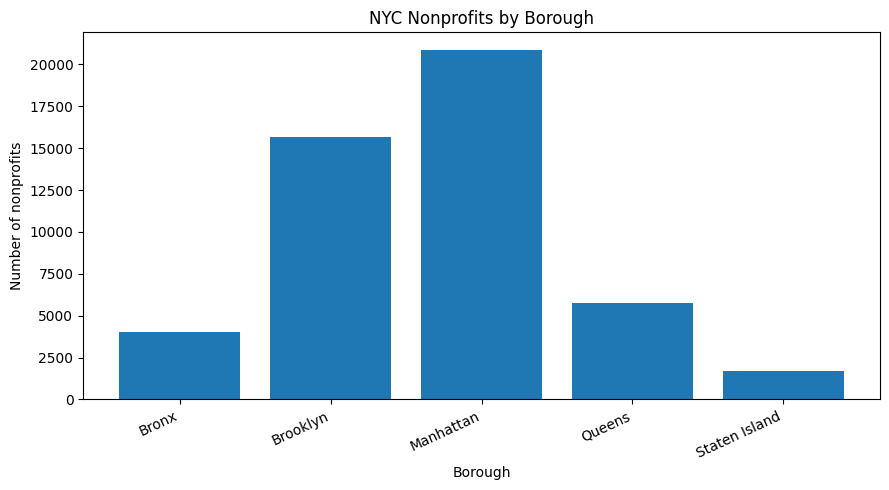

In [7]:
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

borough_counts = (
    df[df["BOROUGH"] != "Unknown"]["BOROUGH"]
    .value_counts()
    .reindex(borough_order)
)

display(borough_counts.to_frame("nonprofit_count"))

plt.figure(figsize=(9, 5))
plt.bar(borough_counts.index, borough_counts.values)
plt.title("NYC Nonprofits by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of nonprofits")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_nonprofits_by_borough.png", dpi=160)
plt.show()


### Visualization 2: Faith-based nonprofits by borough

I define faith-based organizations as records with an NTEE code beginning with **X**, the major NTEE category for religion-related organizations.

Brooklyn leads this category even though Manhattan has more nonprofits overall. That difference was one of the findings that originally motivated me to continue the project.


Total religion-related / faith-based nonprofits: 8407


,faith_based_count
BOROUGH,
Bronx,1028
Brooklyn,4699
Manhattan,992
Queens,1448
Staten Island,239


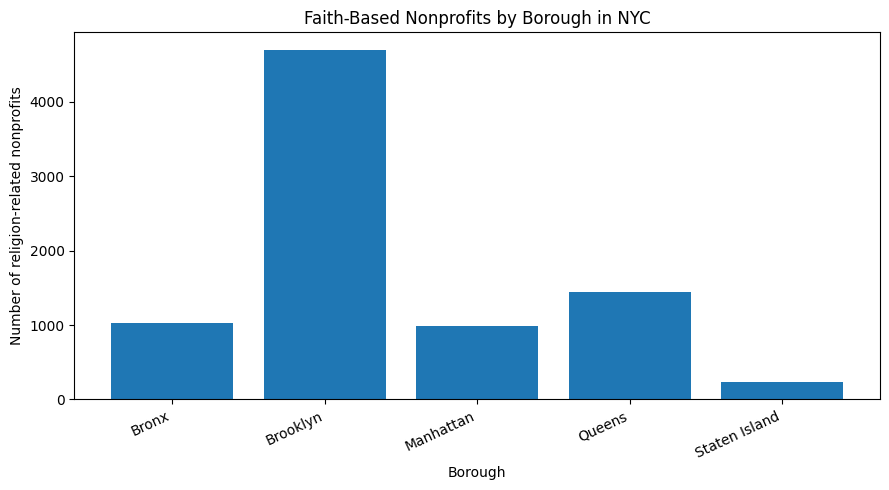

In [8]:
faith_df = filter_by_ntee(df, "X")

faith_by_borough = (
    faith_df[faith_df["BOROUGH"] != "Unknown"]["BOROUGH"]
    .value_counts()
    .reindex(borough_order)
)

print("Total religion-related / faith-based nonprofits:", len(faith_df))
display(faith_by_borough.to_frame("faith_based_count"))

plt.figure(figsize=(9, 5))
plt.bar(faith_by_borough.index, faith_by_borough.values)
plt.title("Faith-Based Nonprofits by Borough in NYC")
plt.xlabel("Borough")
plt.ylabel("Number of religion-related nonprofits")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_faith_based_by_borough.png", dpi=160)
plt.show()


### Visualization 3: Child welfare, adoption, foster care, and youth nonprofits

For this focused analysis, I use an operational definition that includes organizations whose NTEE code begins with `P3` or whose name contains terms such as `child`, `adoption`, `foster`, or `youth`.

This is intentionally broader than adoption alone. It gives a consistent way to identify organizations related to children and youth, but it should not be interpreted as a perfect classification of every organization's services.


Total child welfare/adoption/youth nonprofits: 1112


,child_welfare_count
BOROUGH,
Bronx,133
Brooklyn,365
Manhattan,427
Queens,138
Staten Island,49


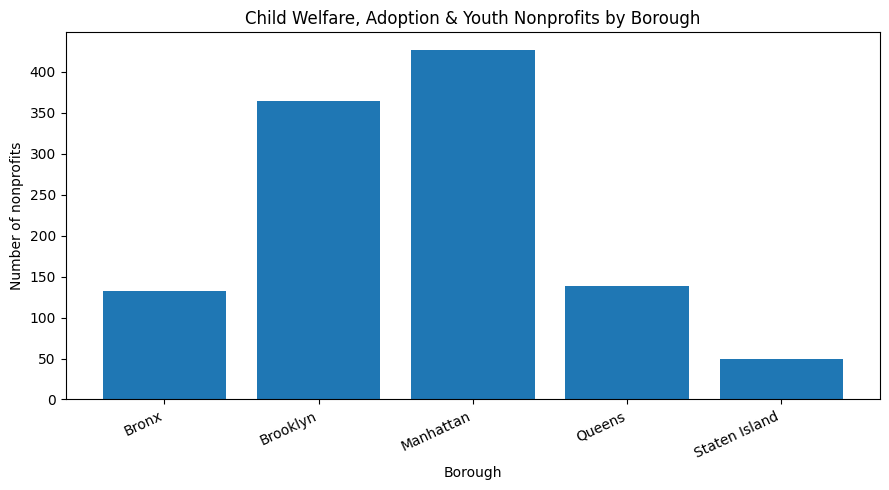

In [9]:
child_welfare_df = df[
    df["NTEE_CD"].fillna("").astype(str).str.startswith("P3")
    | df["NAME"].str.contains(
        "CHILD|ADOPTION|FOSTER|YOUTH",
        case=False,
        na=False,
        regex=True,
    )
].copy()

child_by_borough = (
    child_welfare_df[child_welfare_df["BOROUGH"] != "Unknown"]["BOROUGH"]
    .value_counts()
    .reindex(borough_order)
)

print("Total child welfare/adoption/youth nonprofits:", len(child_welfare_df))
display(child_by_borough.to_frame("child_welfare_count"))

plt.figure(figsize=(9, 5))
plt.bar(child_by_borough.index, child_by_borough.values)
plt.title("Child Welfare, Adoption & Youth Nonprofits by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of nonprofits")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 5. Load Dataset 2: Census poverty data

The second dataset comes from the **2022 American Community Survey 5-Year Subject Table S1701**. I use:

- total population for whom poverty status is determined,
- number below the poverty level,
- percent below the poverty level.

The Census uses counties, so I mapped the five NYC counties to their corresponding borough names. `pull_census_data.py` performs the API request and saves the result used below.


In [10]:
census_df = pd.read_csv(DATA_DIR / "census_poverty_2022.csv")

# Preserve county FIPS codes as three-character strings for display.
census_df["COUNTY_FIPS"] = (
    census_df["COUNTY_FIPS"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(3)
)

for column in ["TOTAL_POPULATION", "BELOW_POVERTY", "POVERTY_RATE"]:
    census_df[column] = pd.to_numeric(census_df[column], errors="coerce")

print("Census rows and columns:", census_df.shape)
display(census_df.sort_values("POVERTY_RATE", ascending=False))


Census rows and columns: (5, 8)


,BOROUGH,COUNTY,COUNTY_FIPS,TOTAL_POPULATION,BELOW_POVERTY,POVERTY_RATE,YEAR,SOURCE_TABLE
0,Bronx,"Bronx County, New York",005,1411574,379925,26.9,2022,ACS 5-Year Subject Table S1701
1,Brooklyn,"Kings County, New York",047,2653797,503524,19.0,2022,ACS 5-Year Subject Table S1701
2,Manhattan,"New York County, New York",061,1599733,252677,15.8,2022,ACS 5-Year Subject Table S1701
3,Queens,"Queens County, New York",081,2334022,272926,11.7,2022,ACS 5-Year Subject Table S1701
4,Staten Island,"Richmond County, New York",085,487849,50556,10.4,2022,ACS 5-Year Subject Table S1701


The Bronx has the highest poverty rate in the Census data, followed by Brooklyn. This gives me a community-need measure that can be compared with nonprofit presence.


## 6. Meaningfully combine the two datasets

The shared key is `BOROUGH`. I merge the borough-level Census fields onto each nonprofit record with a valid borough.

This produces a combined dataset with **more than 48,000 rows and more than 10 columns**, so the nonprofit records and poverty measures can be analyzed together rather than only side by side.


In [11]:
known_borough_df = df[df["BOROUGH"] != "Unknown"].copy()

combined_df = known_borough_df.merge(
    census_df,
    on="BOROUGH",
    how="inner",
    validate="many_to_one",
)

print("Combined dataset shape:", combined_df.shape)
display(combined_df.head())


Combined dataset shape: (48055, 24)


,EIN,NAME,CITY,STATE,ZIP,SUBSECTION,RULING,ASSET_AMT,INCOME_AMT,REVENUE_AMT,NTEE_CD,BOROUGH,NTEE_MAJOR,IS_FAITH_BASED,ASSET_AMT_NEGATIVE_FLAG,INCOME_AMT_NEGATIVE_FLAG,REVENUE_AMT_NEGATIVE_FLAG,COUNTY,COUNTY_FIPS,TOTAL_POPULATION,BELOW_POVERTY,POVERTY_RATE,YEAR,SOURCE_TABLE
0,2022084,ST ROSALIAS ROMAN CATHOLIC CHURCH,BROOKLYN,NY,11219-5614,3,194603,NaN,NaN,NaN,NaN,Brooklyn,,0,0,0,0,"Kings County, New York",047,2653797,503524,19.0,2022,ACS 5-Year Subject Table S1701
1,10263908,SKOWHEGAN SCHOOL OF PAINTING AND SCULPTURE INC,NEW YORK,NY,10011-2424,3,194707,44834975.0,20752787.0,5400296.0,A250,Manhattan,A,0,0,0,0,"New York County, New York",061,1599733,252677,15.8,2022,ACS 5-Year Subject Table S1701
2,10391592,MAINE JAZZ CAMP,BROOKLYN,NY,11215-0000,3,198809,18014.0,33133.0,33133.0,B99Z,Brooklyn,B,0,0,0,0,"Kings County, New York",047,2653797,503524,19.0,2022,ACS 5-Year Subject Table S1701
3,10451903,ILLUMINATING ENGINEERING SOCIETY,NEW YORK,NY,10004-2783,3,199102,0.0,0.0,0.0,NaN,Manhattan,,0,0,0,0,"New York County, New York",061,1599733,252677,15.8,2022,ACS 5-Year Subject Table S1701
4,10550737,AMERICAN AMATEUR SAMBO FEDERATION INC,BROOKLYN,NY,11235-8441,3,200608,0.0,0.0,0.0,N70,Brooklyn,N,0,0,0,0,"Kings County, New York",047,2653797,503524,19.0,2022,ACS 5-Year Subject Table S1701


### Create a borough-level comparison

Raw counts can be misleading because boroughs have different population sizes. To make the comparison fairer, I aggregate the nonprofit data by borough and calculate **nonprofits per 10,000 residents**. I also calculate the same population-adjusted measure for Human Services organizations (major NTEE category `P`).


In [12]:
borough_summary = (
    known_borough_df.groupby("BOROUGH")
    .agg(
        NONPROFIT_COUNT=("EIN", "count"),
        FAITH_BASED_COUNT=("IS_FAITH_BASED", "sum"),
        HUMAN_SERVICES_COUNT=("NTEE_MAJOR", lambda values: (values == "P").sum()),
    )
    .reset_index()
)

borough_summary = borough_summary.merge(
    census_df,
    on="BOROUGH",
    how="left",
    validate="one_to_one",
)

borough_summary["NONPROFITS_PER_10K"] = borough_summary.apply(
    lambda row: calculate_nonprofit_density(
        row["NONPROFIT_COUNT"], row["TOTAL_POPULATION"]
    ),
    axis=1,
)

borough_summary["HUMAN_SERVICES_PER_10K"] = borough_summary.apply(
    lambda row: calculate_nonprofit_density(
        row["HUMAN_SERVICES_COUNT"], row["TOTAL_POPULATION"]
    ),
    axis=1,
)

borough_summary = borough_summary.sort_values(
    "POVERTY_RATE", ascending=False
).reset_index(drop=True)

display(
    borough_summary[
        [
            "BOROUGH",
            "TOTAL_POPULATION",
            "POVERTY_RATE",
            "NONPROFIT_COUNT",
            "NONPROFITS_PER_10K",
            "HUMAN_SERVICES_COUNT",
            "HUMAN_SERVICES_PER_10K",
        ]
    ]
)

borough_summary.to_csv(DATA_DIR / "borough_summary_merged.csv", index=False)


,BOROUGH,TOTAL_POPULATION,POVERTY_RATE,NONPROFIT_COUNT,NONPROFITS_PER_10K,HUMAN_SERVICES_COUNT,HUMAN_SERVICES_PER_10K
0,Bronx,1411574,26.9,4042,28.634701,445,3.152509
1,Brooklyn,2653797,19.0,15697,59.149211,1226,4.619796
2,Manhattan,1599733,15.8,20872,130.471772,1325,8.282632
3,Queens,2334022,11.7,5729,24.545613,506,2.167932
4,Staten Island,487849,10.4,1715,35.154320,160,3.279703


## 7. Visualization 4: Poverty rate vs. nonprofit density

This scatter plot directly addresses the main capstone question. Points farther to the right have higher poverty rates; points higher on the chart have more nonprofits per 10,000 residents.

If nonprofit concentration closely followed poverty, I would expect the highest-poverty boroughs to also appear near the top of the chart. Instead, Manhattan has by far the highest nonprofit density even though the Bronx has the highest poverty rate.


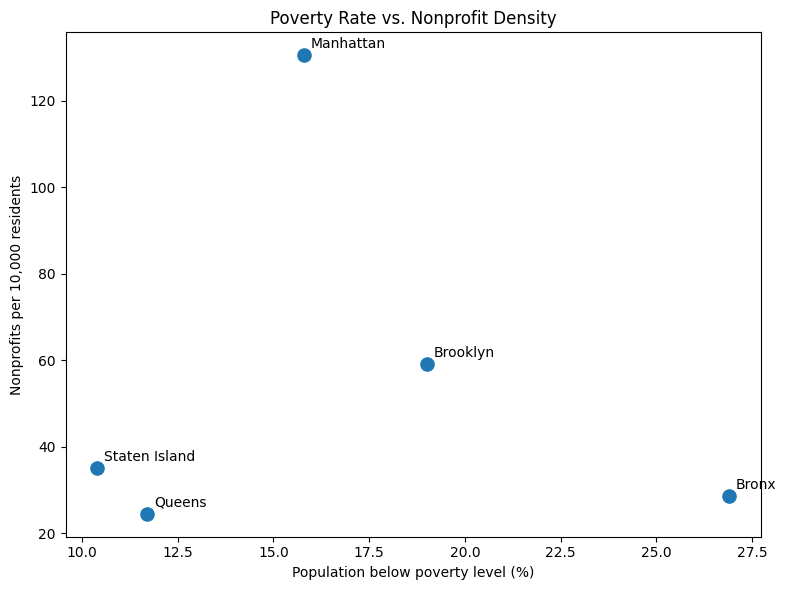

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    borough_summary["POVERTY_RATE"],
    borough_summary["NONPROFITS_PER_10K"],
    s=90,
)

for _, row in borough_summary.iterrows():
    plt.annotate(
        row["BOROUGH"],
        (row["POVERTY_RATE"], row["NONPROFITS_PER_10K"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Poverty Rate vs. Nonprofit Density")
plt.xlabel("Population below poverty level (%)")
plt.ylabel("Nonprofits per 10,000 residents")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_poverty_vs_nonprofit_density.png", dpi=160)
plt.show()


### What the scatter plot suggests

The relationship is uneven. The **Bronx has the highest poverty rate (26.9%)**, but its nonprofit density is much lower than Manhattan's. Manhattan has a poverty rate of 15.8% but the highest nonprofit density by a wide margin.

That does **not** prove that the Bronx is underserved, because an organization's headquarters may not match the neighborhoods it serves. It does show that the physical concentration of nonprofit organizations does not simply rise with borough poverty.


## 8. Visualization 5: NTEE category breakdown

To add a third chart type and understand the nonprofit sector beyond the focused categories, I look at the ten most common major NTEE categories among records that have an NTEE code.


,NTEE_MAJOR,CATEGORY,COUNT
0,X,Religion-related,8406
1,A,Arts/Culture,5243
2,T,Philanthropy,4750
3,B,Education,3790
4,P,Human Services,3662
5,S,Community Improvement,1704
6,Q,International,1237
7,L,Housing,1167
8,N,Recreation/Sports,1126
9,O,Youth Development,1030


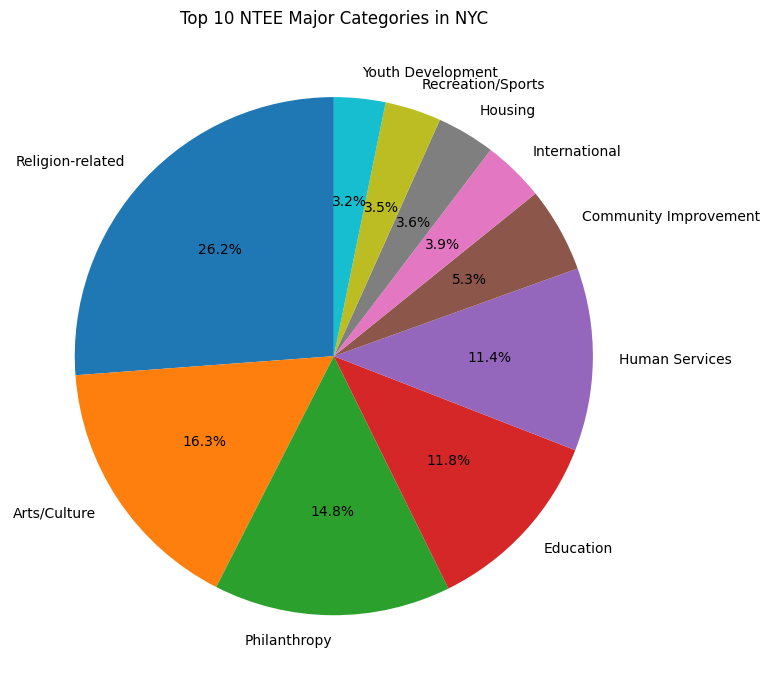

In [14]:
ntee_labels = {
    "A": "Arts/Culture",
    "B": "Education",
    "C": "Environment",
    "D": "Animal-related",
    "E": "Health",
    "F": "Mental Health",
    "G": "Diseases/Disorders",
    "H": "Medical Research",
    "I": "Crime/Legal",
    "J": "Employment",
    "K": "Food/Agriculture",
    "L": "Housing",
    "M": "Public Safety",
    "N": "Recreation/Sports",
    "O": "Youth Development",
    "P": "Human Services",
    "Q": "International",
    "R": "Civil Rights",
    "S": "Community Improvement",
    "T": "Philanthropy",
    "U": "Science/Technology",
    "V": "Social Science",
    "W": "Public Benefit",
    "X": "Religion-related",
    "Y": "Mutual Benefit",
    "Z": "Unknown/Unclassified",
}

top_ntee = (
    known_borough_df.loc[
        known_borough_df["NTEE_MAJOR"] != "",
        "NTEE_MAJOR",
    ]
    .value_counts()
    .head(10)
)

pie_labels = [ntee_labels.get(code, code) for code in top_ntee.index]

display(
    pd.DataFrame(
        {
            "NTEE_MAJOR": top_ntee.index,
            "CATEGORY": pie_labels,
            "COUNT": top_ntee.values,
        }
    )
)

plt.figure(figsize=(9, 7))
plt.pie(
    top_ntee.values,
    labels=pie_labels,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Top 10 NTEE Major Categories in NYC")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_ntee_category_breakdown_pie.png", dpi=160)
plt.show()


## 9. Relational database design

I use SQLite because the project naturally contains two related entities:

- **`borough_poverty`**: one record for each NYC borough and its Census poverty measures.
- **`nonprofits`**: many nonprofit records, each linked to a borough.

The relationship is **one borough to many nonprofits**. Keeping the Census data in its own table avoids repeating the same borough-level poverty values as stored database records and makes the relationship clear.


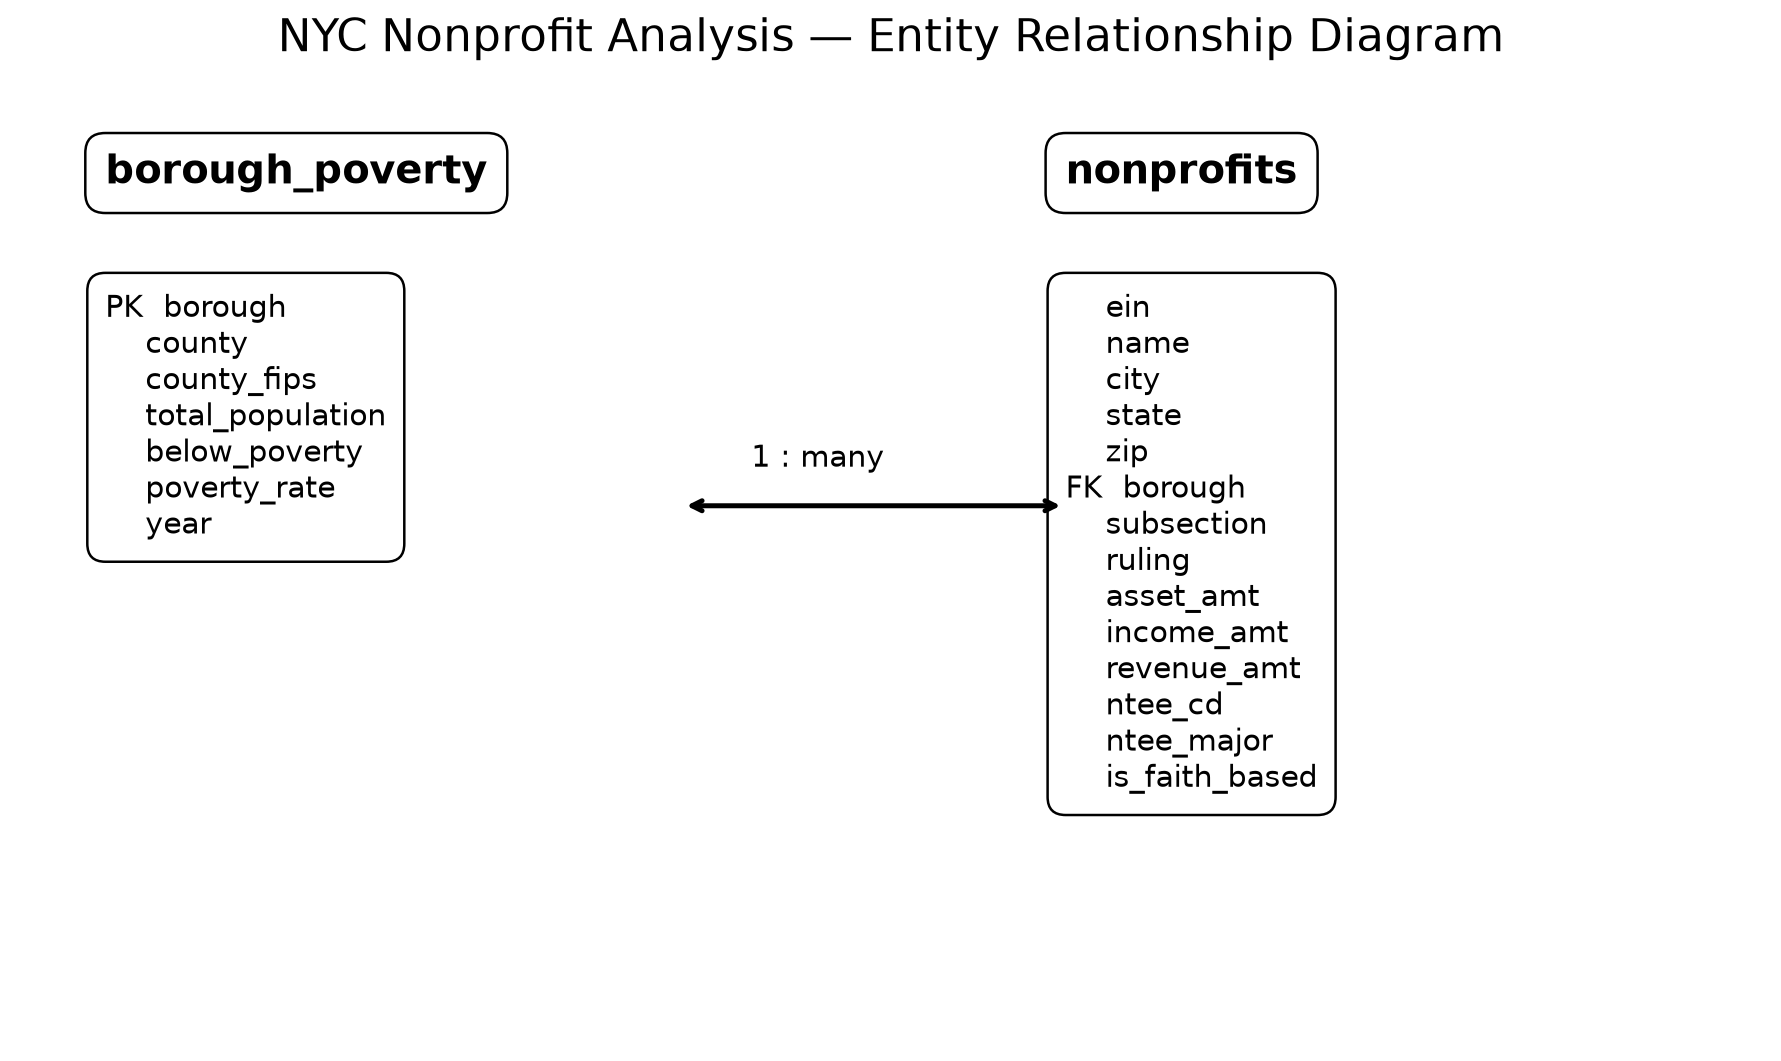

In [15]:
# Display the ERD included in the repository.
display(Image(filename=str(DATABASE_DIR / "erd.png")))


### Build the SQLite database with Python

The following cell rebuilds the database from the cleaned nonprofit data and the Census data. This makes the database reproducible rather than relying only on a prebuilt `.db` file.


In [16]:
database_path = DATABASE_DIR / "nyc_nonprofit.db"

if database_path.exists():
    database_path.unlink()

conn = sqlite3.connect(database_path)
conn.execute("PRAGMA foreign_keys = ON;")

conn.execute(
    '''
    CREATE TABLE borough_poverty (
        borough TEXT PRIMARY KEY,
        county TEXT NOT NULL,
        county_fips TEXT NOT NULL,
        total_population INTEGER NOT NULL,
        below_poverty INTEGER,
        poverty_rate REAL NOT NULL,
        year INTEGER NOT NULL
    )
    '''
)

conn.execute(
    '''
    CREATE TABLE nonprofits (
        ein INTEGER,
        name TEXT NOT NULL,
        city TEXT,
        state TEXT,
        zip TEXT,
        borough TEXT NOT NULL,
        subsection REAL,
        ruling REAL,
        asset_amt REAL,
        income_amt REAL,
        revenue_amt REAL,
        ntee_cd TEXT,
        ntee_major TEXT,
        is_faith_based INTEGER NOT NULL DEFAULT 0,
        FOREIGN KEY (borough) REFERENCES borough_poverty(borough)
    )
    '''
)

borough_db = census_df[
    [
        "BOROUGH",
        "COUNTY",
        "COUNTY_FIPS",
        "TOTAL_POPULATION",
        "BELOW_POVERTY",
        "POVERTY_RATE",
        "YEAR",
    ]
].copy()
borough_db.columns = [column.lower() for column in borough_db.columns]
borough_db.to_sql("borough_poverty", conn, if_exists="append", index=False)

nonprofit_db = known_borough_df[
    [
        "EIN",
        "NAME",
        "CITY",
        "STATE",
        "ZIP",
        "BOROUGH",
        "SUBSECTION",
        "RULING",
        "ASSET_AMT",
        "INCOME_AMT",
        "REVENUE_AMT",
        "NTEE_CD",
        "NTEE_MAJOR",
        "IS_FAITH_BASED",
    ]
].copy()
nonprofit_db.columns = [column.lower() for column in nonprofit_db.columns]
nonprofit_db.to_sql("nonprofits", conn, if_exists="append", index=False)

conn.execute(
    "CREATE INDEX idx_nonprofits_borough ON nonprofits(borough)"
)
conn.execute(
    "CREATE INDEX idx_nonprofits_ntee ON nonprofits(ntee_major)"
)

conn.commit()

table_check = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn,
)
display(table_check)


,name
0,borough_poverty
1,nonprofits


## 10. SQL analysis

The rubric asks for at least three intermediate or advanced SQL queries. The queries below use joins, filtering, grouping/aggregation, and a subquery.


### SQL Query 1: Nonprofit density by borough

This query joins the nonprofit and poverty tables, groups by borough, and calculates population-adjusted nonprofit density.


In [17]:
query_1 = '''
SELECT
    n.borough,
    COUNT(*) AS nonprofit_count,
    p.total_population,
    p.poverty_rate,
    ROUND(COUNT(*) * 10000.0 / p.total_population, 2) AS nonprofits_per_10k
FROM nonprofits AS n
JOIN borough_poverty AS p
    ON n.borough = p.borough
GROUP BY n.borough, p.total_population, p.poverty_rate
ORDER BY nonprofits_per_10k DESC;
'''

display(pd.read_sql_query(query_1, conn))


,borough,nonprofit_count,total_population,poverty_rate,nonprofits_per_10k
0,Manhattan,20872,1599733,15.8,130.47
1,Brooklyn,15697,2653797,19.0,59.15
2,Staten Island,1715,487849,10.4,35.15
3,Bronx,4042,1411574,26.9,28.63
4,Queens,5729,2334022,11.7,24.55


### SQL Query 2: Faith-based nonprofits by borough

This query adds a `WHERE` condition to the join and aggregation so only religion-related nonprofits are counted.


In [18]:
query_2 = '''
SELECT
    n.borough,
    COUNT(*) AS faith_based_nonprofits,
    p.poverty_rate
FROM nonprofits AS n
JOIN borough_poverty AS p
    ON n.borough = p.borough
WHERE n.is_faith_based = 1
GROUP BY n.borough, p.poverty_rate
ORDER BY faith_based_nonprofits DESC;
'''

display(pd.read_sql_query(query_2, conn))


,borough,faith_based_nonprofits,poverty_rate
0,Brooklyn,4699,19.0
1,Queens,1448,11.7
2,Bronx,1028,26.9
3,Manhattan,992,15.8
4,Staten Island,239,10.4


### SQL Query 3: Human Services organizations and poverty

This query filters to major NTEE category `P`, joins the Census table, groups the results, and calculates Human Services organizations per 10,000 residents.


In [19]:
query_3 = '''
SELECT
    n.borough,
    COUNT(*) AS human_services_nonprofits,
    p.poverty_rate,
    ROUND(COUNT(*) * 10000.0 / p.total_population, 2) AS human_services_per_10k
FROM nonprofits AS n
JOIN borough_poverty AS p
    ON n.borough = p.borough
WHERE n.ntee_major = 'P'
GROUP BY n.borough, p.total_population, p.poverty_rate
ORDER BY p.poverty_rate DESC;
'''

display(pd.read_sql_query(query_3, conn))


,borough,human_services_nonprofits,poverty_rate,human_services_per_10k
0,Bronx,445,26.9,3.15
1,Brooklyn,1226,19.0,4.62
2,Manhattan,1325,15.8,8.28
3,Queens,506,11.7,2.17
4,Staten Island,160,10.4,3.28


### SQL Query 4: Above-average borough poverty

This final query uses a subquery to identify boroughs whose poverty rate is above the average of the five NYC borough rates in this dataset.


In [20]:
query_4 = '''
SELECT
    borough,
    poverty_rate
FROM borough_poverty
WHERE poverty_rate > (
    SELECT AVG(poverty_rate)
    FROM borough_poverty
)
ORDER BY poverty_rate DESC;
'''

display(pd.read_sql_query(query_4, conn))

conn.close()


,borough,poverty_rate
0,Bronx,26.9
1,Brooklyn,19.0


## 11. Findings

The combined analysis adds an important layer to the original IRS findings:

1. **Manhattan has the most nonprofits overall.** It contains 20,872 of the nonprofit records assigned to the five boroughs.
2. **Brooklyn leads in faith-based nonprofits.** It has 4,699 religion-related organizations under the NTEE `X` definition, even though Manhattan has more nonprofits overall.
3. **The child welfare/adoption/youth search identifies 1,112 organizations.** Manhattan and Brooklyn contain the largest counts.
4. **The Bronx has the highest poverty rate at 26.9%, but it does not have the highest nonprofit density.**
5. **Manhattan has the highest nonprofit density by a large margin**, despite having a lower poverty rate than the Bronx and Brooklyn.
6. **Nonprofit concentration and poverty do not move together in a simple way.** The physical location of nonprofit organizations appears uneven relative to borough-level poverty.

The main conclusion is not that a particular borough definitely lacks services. Instead, the data show a meaningful difference between **where nonprofit organizations are registered** and **where poverty is highest**, which is a useful starting point for more detailed neighborhood-level analysis.


## 12. Limitations and next steps

There are several reasons to be careful with the conclusions:

- The Census data are at the **borough/county level**, so they hide large differences between neighborhoods.
- About 10,000 IRS records are missing NTEE codes, which limits category analysis.
- A nonprofit's registered address does not necessarily represent the communities it actually serves.
- The child welfare/adoption/youth definition is a practical keyword/NTEE filter rather than a perfect program classification.
- The poverty-versus-density scatter plot has only five borough observations, so it should be treated as **descriptive**, not as evidence of causation.

A strong next step would be ZIP-code or neighborhood-level analysis using more detailed Census geography and, if available, actual nonprofit service-area information.


## 13. Reproducibility

The repository includes:

- `analysis.ipynb` — the complete analysis and narrative
- `eo1_nyc (1).csv` — the NYC IRS nonprofit extract
- `pull_census_data.py` — reproducible Census API pull
- `functions.py` — three reusable custom functions
- `data/census_poverty_2022.csv` — Census poverty dataset
- `data/nonprofits_cleaned.csv` — cleaned nonprofit dataset
- `data/borough_summary_merged.csv` — borough comparison dataset
- `database/nyc_nonprofit.db` — SQLite database
- `database/queries.sql` — saved SQL queries
- `database/erd.png` — entity relationship diagram
- `charts/` — exported figures
- `requirements.txt` — Python dependencies

All paths used in the notebook are relative so the project can be run from the repository folder on different operating systems.
